In [1]:
import pandas as pd

# Load the Excel file to inspect its content
file_path = 'Mkt Data.xlsx'
# Reading the first sheet to understand structure
df = pd.read_excel(file_path, sheet_name=0)

# Display head and info
df.head(20)
df = df[['Unnamed: 0', 'MAT', 'MKT']].copy()
df.columns = ['Instrument', 'Maturity', 'MarketRate']
df_clean = df.copy()
display(df_clean)

,Instrument,Maturity,MarketRate
0,MM,0.25,0.030698
1,MM,0.50,0.026192
2,MM,0.75,0.023958
3,MM,1.00,0.022980
4,FUT,1.25,0.978692
5,FUT,1.50,0.977095
6,FUT,1.75,0.974982
7,FUT,2.00,0.972912
8,FUT,2.25,0.970984
9,FUT,2.50,0.969711


# rmq : FUT 1.25 est le futur entre 1 et 1.25 an 


In [2]:
import numpy as np

df_clean = df_clean.sort_values(by='Maturity')

results = []
curve = {0.0: 1.0}

for index, row in df_clean.iterrows():
    instr = row['Instrument']
    mat = row['Maturity']
    rate = row['MarketRate']

    df_val = np.nan
    zc_rate = np.nan

    if instr == 'MM':
        df_val = 1.0 / (1.0 + rate * mat)

    elif instr == 'FUT':
        implied_rate = 1.0 - rate
        delta = 0.25
        prev_mat = mat - delta

        prev_mat_key = round(prev_mat, 2)
        if prev_mat_key in curve:
             df_prev = curve[prev_mat_key]
        else:
             keys = np.array(list(curve.keys()))
             closest_key = keys[np.abs(keys - prev_mat_key).argmin()]
             df_prev = curve[closest_key]

        df_val = df_prev / (1.0 + implied_rate * delta)

    elif instr == 'SWAP':
        coupon_dates = np.arange(1, int(mat))
        sum_df = 0.0
        for t in coupon_dates:
            t_key = round(float(t), 2)
            if t_key in curve:
                sum_df += curve[t_key]

        df_val = (1.0 - rate * sum_df) / (1.0 + rate)

    curve[round(mat, 2)] = df_val

    if mat > 0:
        zc_rate = -np.log(df_val) / mat

    results.append({
        'Instrument': instr,
        'Maturity': mat,
        'MarketData': rate,
        'DiscountFactor': df_val,
        'ZeroCouponRate': zc_rate *100
    })

df_results = pd.DataFrame(results)
print(df_results)

   Instrument  Maturity  MarketData  DiscountFactor  ZeroCouponRate
0          MM      0.25    0.030698        0.992384        3.058080
1          MM      0.50    0.026192        0.987073        2.602198
2          MM      0.75    0.023958        0.982349        2.374530
3          MM      1.00    0.022980        0.977536        2.271994
4         FUT      1.25    0.978692        0.972356        2.242624
5         FUT      1.50    0.977095        0.966820        2.249514
6         FUT      1.75    0.974982        0.960811        2.284442
7         FUT      2.00    0.972912        0.954348        2.336346
8         FUT      2.25    0.970984        0.947475        2.397988
9         FUT      2.50    0.969711        0.940354        2.459938
10        FUT      2.75    0.968436        0.932992        2.522127
11       SWAP      3.00    0.026112        0.925391        2.584637
12       SWAP      4.00    0.028118        0.894507        2.787053
13       SWAP      5.00    0.029681        0.863

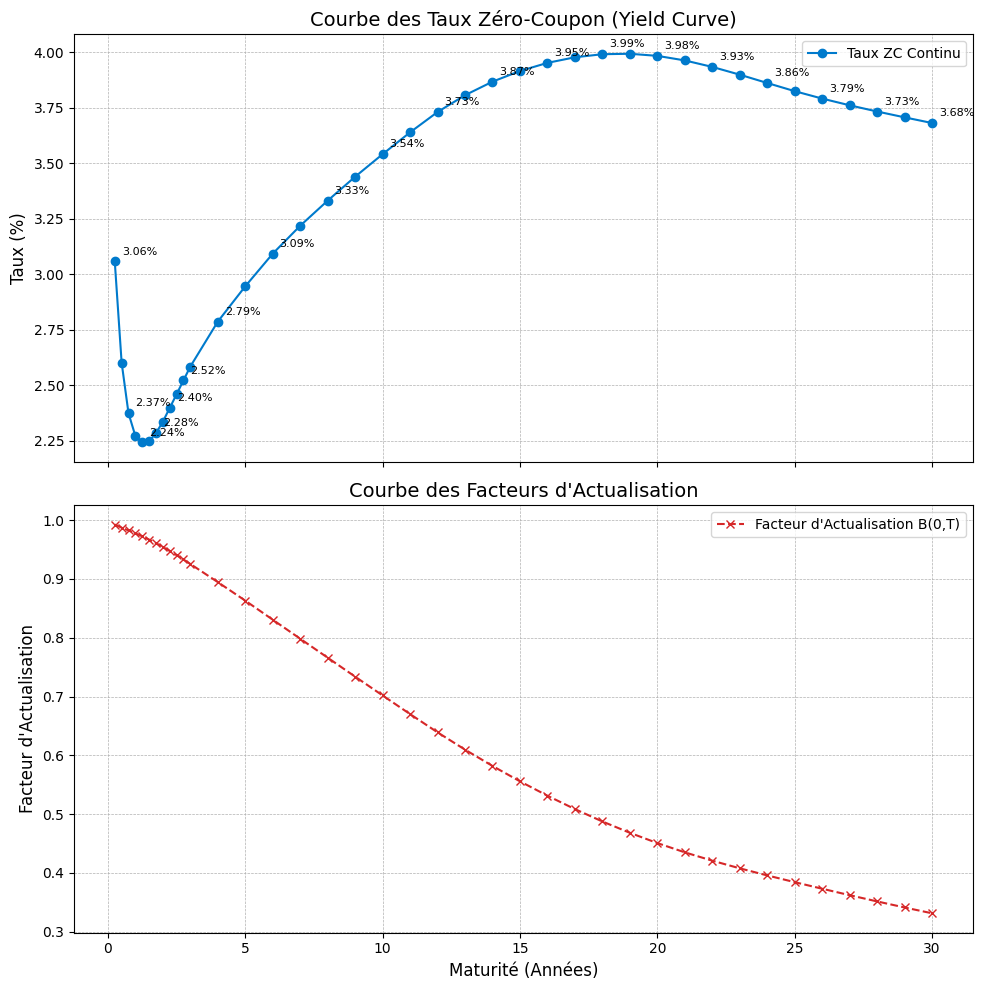

In [4]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

ax1.plot(df_results['Maturity'], df_results['ZeroCouponRate'], marker='o', linestyle='-', color='#007acc', label='Taux ZC Continu')
ax1.set_title('Courbe des Taux Zéro-Coupon (Yield Curve)', fontsize=14)
ax1.set_ylabel('Taux (%)', fontsize=12)
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
ax1.legend()

for i, txt in enumerate(df_results['ZeroCouponRate']):
    if i % 2 == 0 or i == len(df_results)-1:
        ax1.annotate(f"{txt:.2f}%", (df_results['Maturity'].iloc[i], df_results['ZeroCouponRate'].iloc[i]),
                     xytext=(5, 5), textcoords='offset points', fontsize=8)

ax2.plot(df_results['Maturity'], df_results['DiscountFactor'], marker='x', linestyle='--', color='#d62728', label='Facteur d\'Actualisation B(0,T)')
ax2.set_title('Courbe des Facteurs d\'Actualisation', fontsize=14)
ax2.set_xlabel('Maturité (Années)', fontsize=12)
ax2.set_ylabel('Facteur d\'Actualisation', fontsize=12)
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)
ax2.legend()

plt.tight_layout()
plt.show()

### Question 1.2.3 : Le mode d'interpolation a-t-il un impact sur le calcul des taux de marché ?

**Réponse : OUI.**

Le choix de la méthode d'interpolation (Linéaire, Log-linéaire, Splines cubiques) a un impact sur la construction de la courbe et les taux calculés, pour trois raisons fondamentales :

**1. La gestion des "trous de liquidité" (Gaps de maturité)**
Sur le long terme, les instruments ne sont pas cotés toutes les années (exemple : on passe souvent de 15 ans à 20 ans, puis 30 ans).
* Pour calibrer le point à 20 ans, le bootstrapping doit valoriser les coupons des années 16, 17, 18 et 19.
* Comme il n'y a pas de taux de marché pour ces dates, le modèle utilise la valeur interpolée.
* **Conséquence :** Si l'interpolation change, la valeur actuelle (PV) de ces coupons intermédiaires change. Pour que le Swap reste valorisé à par (PV = 0), le facteur d'actualisation final ($T=20$) s'ajuste mécaniquement, modifiant ainsi le taux Zéro-Coupon calculé.

**2. La cohérence de la courbe des Taux Forward (Aspect qualitatif)**
C'est l'impact le plus visible graphiquement. Le taux Forward est mathématiquement lié à la pente (dérivée) de la courbe Zéro-Coupon.
* **Interpolation Linéaire sur les ZC :** La courbe est une suite de segments droits. La dérivée est constante par morceaux mais "casse" à chaque nœud. Cela produit une courbe des taux Forward **"en escalier"**, ce qui est économiquement irréaliste.
* **Splines Cubiques :** Elles assurent la continuité de la dérivée seconde. Cela produit une courbe Forward **lisse et continue**, ce qui est indispensable pour valoriser correctement des produits dérivés sensibles à la volatilité (Swaptions, Caps/Floors).

**3. Le désalignement des fréquences de paiement**
Les swaps standards échangent souvent une jambe fixe annuelle contre une jambe variable semestrielle.
* Même si l'on dispose de cotations annuelles (1Y, 2Y...), la valorisation de la jambe variable nécessite des facteurs d'actualisation aux dates semestrielles ($T+0.5, T+1.5...$).
* Ces points n'étant pas cotés, leur valeur dépend entièrement de la règle d'interpolation choisie.

# On fait l'hypothèse d'un interpolation


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, CubicSpline
from scipy.optimize import root_scalar

# --- 1. FONCTION DE BOOTSTRAPPING ---
def run_bootstrap(df_input):
    df = df_input.sort_values(by='Maturity').copy()
    curve_points = []

    for index, row in df.iterrows():
        instr = row['Instrument']
        mat = row['Maturity']
        rate = row['MarketRate']

        df_val = np.nan

        if instr == 'MM':
            df_val = 1.0 / (1.0 + rate * mat)

        elif instr == 'FUT':
            # Si le taux est un prix (ex: 0.97), on convertit
            if rate > 0.5:
                implied_rate = 1.0 - rate
            else:
                implied_rate = rate

            delta = 0.25
            prev_mat = mat - delta

            # Récupération du point précédent dans la courbe en construction
            if not curve_points:
                df_prev = 1.0
            else:
                closest = min(curve_points, key=lambda x: abs(x[0] - prev_mat))
                df_prev = np.exp(-closest[1] * prev_mat)

            df_val = df_prev / (1.0 + implied_rate * delta)

        elif instr == 'SWAP':
            # Solveur pour trouver le taux ZC qui équilibre le Swap
            def objective(r_guess):
                if not curve_points:
                     last_mat, last_zc = 0, 0
                else:
                     last_mat, last_zc = curve_points[-1]

                pv_fixed = 0.0
                coupon_dates = np.arange(1, int(mat) + 1)

                for t in coupon_dates:
                    if t <= last_mat:
                        # On prend le point historique le plus proche
                        closest = min(curve_points, key=lambda x: abs(x[0] - t))
                        r_t = closest[1]
                    else:
                        # Interpolation linéaire entre le dernier point connu et le guess
                        slope = (r_guess - last_zc) / (mat - last_mat)
                        r_t = last_zc + slope * (t - last_mat)

                    df_t = np.exp(-r_t * t)
                    pv_fixed += rate * df_t

                return (pv_fixed + np.exp(-r_guess * mat)) - 1.0

            sol = root_scalar(objective, bracket=[0.0, 1.0], method='brentq')
            zc_decimal = sol.root
            df_val = np.exp(-zc_decimal * mat)

        if mat > 0:
            zc_decimal = -np.log(df_val) / mat
        else:
            zc_decimal = 0

        curve_points.append((mat, zc_decimal))

    # Création du DataFrame de résultats
    res = []
    for (m, zc) in curve_points:
        res.append({'Maturity': m, 'ZeroCouponRate': zc})
    return pd.DataFrame(res)

# --- 2. FONCTION DE CALCUL DE COURBES (ZC & FORWARD) ---
def get_curves_on_grid(df_res, method='linear'):
    mats = df_res['Maturity'].values
    zcs = df_res['ZeroCouponRate'].values

    if method == 'linear':
        interp_func = interp1d(mats, zcs, kind='linear', fill_value='extrapolate')
    elif method == 'spline':
        interp_func = CubicSpline(mats, zcs)

    t_grid = np.linspace(0.25, 30, 500)

    # Calcul ZC interpolé
    zc_values = interp_func(t_grid)

    # Calcul Forward 3M glissant
    fwd_values = []
    tenor = 0.25
    for t in t_grid:
        t2 = t + tenor
        r1 = interp_func(t)
        r2 = interp_func(t2)
        b1 = np.exp(-r1 * t)
        b2 = np.exp(-r2 * t2)
        fwd = (b1/b2 - 1) / tenor
        fwd_values.append(fwd)

    return t_grid, zc_values, np.array(fwd_values)

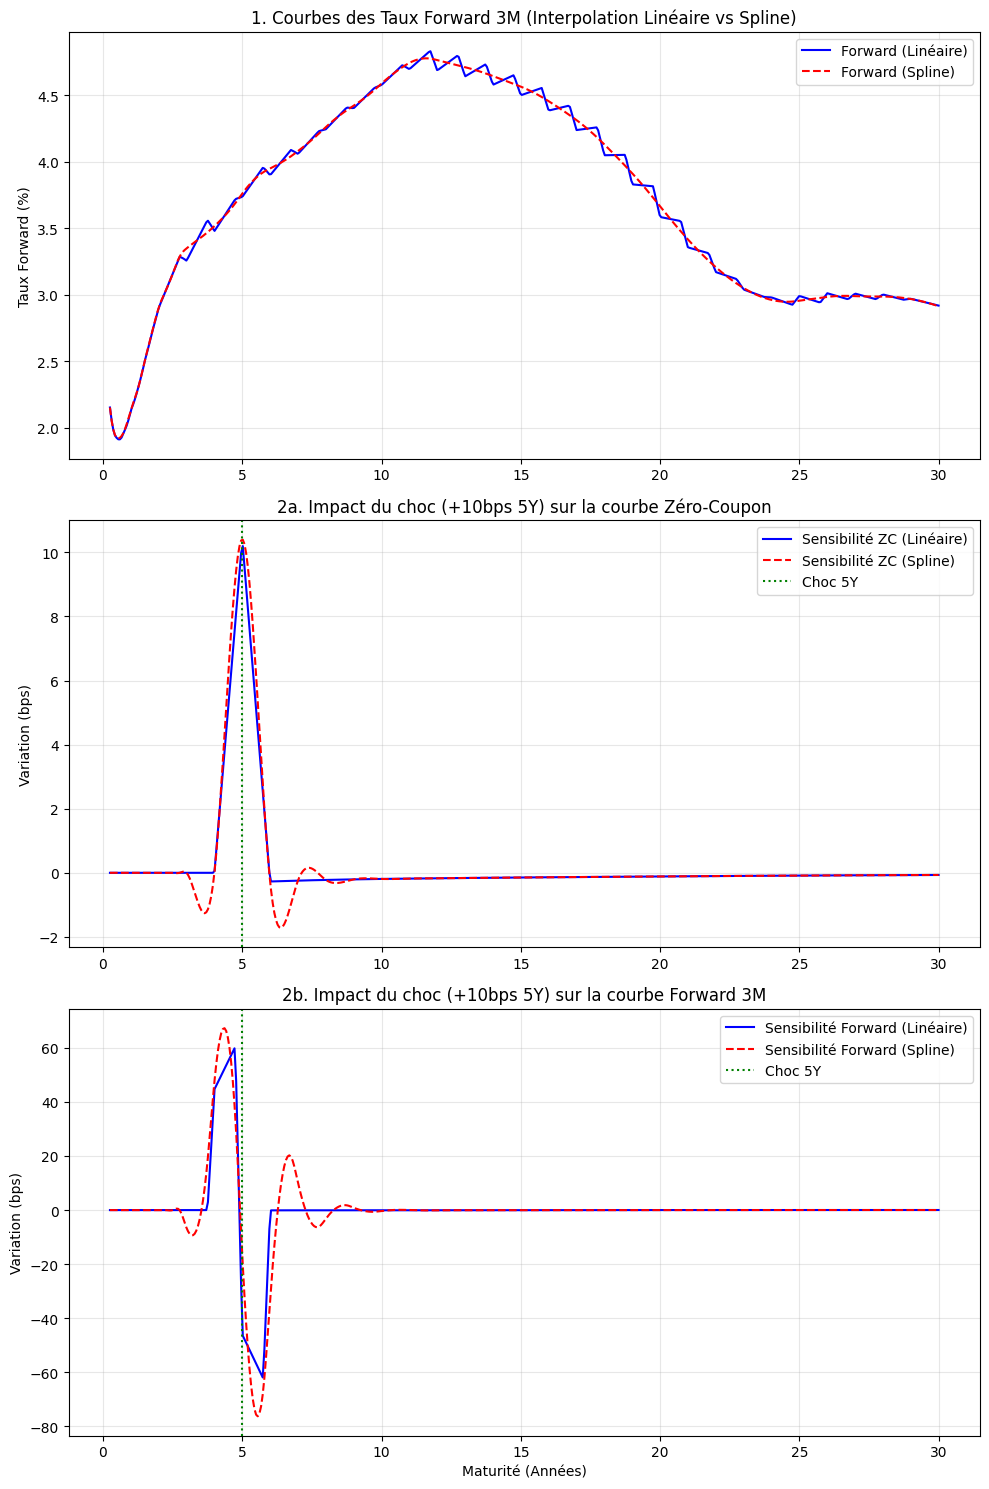

In [ ]:

df_results = run_bootstrap(df_clean)

# B. Cas Choqué (+10 bps sur Swap 5Y)
df_clean_bump = df_clean.copy()
mask_5y = (df_clean_bump['Instrument'] == 'SWAP') & (np.isclose(df_clean_bump['Maturity'], 5.0))
df_clean_bump.loc[mask_5y, 'MarketRate'] += 0.0010
df_results_bump = run_bootstrap(df_clean_bump)

# C. Calcul des courbes pour l'affichage
t, zc_lin_base, fwd_lin_base = get_curves_on_grid(df_results, 'linear')
t, zc_spl_base, fwd_spl_base = get_curves_on_grid(df_results, 'spline')

t, zc_lin_bump, fwd_lin_bump = get_curves_on_grid(df_results_bump, 'linear')
t, zc_spl_bump, fwd_spl_bump = get_curves_on_grid(df_results_bump, 'spline')

# --- 5. AFFICHAGE ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 15))

# Graphique 1 : Taux Forward 3M (Interpolations)
ax1.plot(t, fwd_lin_base * 100, label='Forward (Linéaire)', color='blue')
ax1.plot(t, fwd_spl_base * 100, label='Forward (Spline)', color='red', linestyle='--')
ax1.set_title("1. Courbes des Taux Forward 3M (Interpolation Linéaire vs Spline)")
ax1.set_ylabel("Taux Forward (%)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Graphique 2 : Impact ZC (Différence)
diff_zc_lin = (zc_lin_bump - zc_lin_base) * 10000
diff_zc_spl = (zc_spl_bump - zc_spl_base) * 10000
ax2.plot(t, diff_zc_lin, label='Sensibilité ZC (Linéaire)', color='blue')
ax2.plot(t, diff_zc_spl, label='Sensibilité ZC (Spline)', color='red', linestyle='--')
ax2.axvline(5, color='green', linestyle=':', label='Choc 5Y')
ax2.set_title("2a. Impact du choc (+10bps 5Y) sur la courbe Zéro-Coupon")
ax2.set_ylabel("Variation (bps)")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Graphique 3 : Impact Forward (Différence)
diff_fwd_lin = (fwd_lin_bump - fwd_lin_base) * 10000
diff_fwd_spl = (fwd_spl_bump - fwd_spl_base) * 10000
ax3.plot(t, diff_fwd_lin, label='Sensibilité Forward (Linéaire)', color='blue')
ax3.plot(t, diff_fwd_spl, label='Sensibilité Forward (Spline)', color='red', linestyle='--')
ax3.axvline(5, color='green', linestyle=':', label='Choc 5Y')
ax3.set_title("2b. Impact du choc (+10bps 5Y) sur la courbe Forward 3M")
ax3.set_ylabel("Variation (bps)")
ax3.set_xlabel("Maturité (Années)")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

les vaguelettes proviennent de l'interpolation polynomial.
L'interpolation linéaire localise parfaitement le risque (idéal pour la couverture/hedging) mais produit des taux forwards discontinus (inutilisables pour le pricing). L'interpolation par Spline produit des courbes lisses et réalistes (idéal pour le pricing) mais diffuse le risque sur toute la courbe (effet de pollution globale), rendant la lecture des sensibilités plus complexe.

# Partie 2 

### Q1 
Le modèle standard de marché est le Modèle de Black (aussi appelé Black-76).Les caplets et floorlets ne sont pas cotés en prix, mais en volatilité implicite (la volatilité $\sigma$ qu'il faut injecter dans la formule de Black).Référence Cours :
* Slide 194 : "Le modèle de Black : la référence du marché. Les produits dérivés standards (caps, floors...) sont des options européennes dont les prix sont obtenus dans le modèle de Black." * Slide 197 : "Les caplets et floorlets sont cotés en volatilité, la volatilité implicite de la formule de Black." 

### Question 2 : EDS des taux Libor forwards et Probabilité associée

**1. La Probabilité Associée**
Pour valoriser un Caplet payant à la date $T_i$, on se place sous la **Probabilité Forward Neutre**, notée $\mathbb{Q}^{T_i}$.
* **Numéraire associé :** Le Zéro-Coupon de maturité $T_i$, noté $P(t, T_i)$ ou $B(t, T_i)$.
* **Propriété fondamentale :** Sous cette mesure de probabilité, le taux Forward $L_i(t)$ est une **martingale** (il n'a pas de tendance, son espérance mathématique correspond à sa valeur actuelle).
* *(Référence cours : Slide 192)*

**2. L'Équation Différentielle Stochastique (EDS)**
Dans le modèle de marché (Modèle de Black), le taux Forward suit un **Mouvement Brownien Géométrique** (Lognormal) sous la probabilité Forward Neutre. L'équation de diffusion est :

$$\frac{dL_i(t)}{L_i(t)} = \sigma_i dW_t^{\mathbb{Q}^{T_i}}$$

Soit :
$$dL_i(t) = \sigma_i L_i(t) dW_t^{\mathbb{Q}^{T_i}}$$

Où :
* $L_i(t)$ est le taux Forward Libor/Euribor observé en $t$.
* $\sigma_i$ est la volatilité implicite du taux (Black volatility).
* $dW_t^{\mathbb{Q}^{T_i}}$ est un Mouvement Brownien standard sous la mesure $\mathbb{Q}^{T_i}$.

*(Référence cours : Slide 200)*

### Question 3 : Formules de valorisation des Caplets et Floorlets

Dans le cadre du modèle de marché (Modèle de Black), les Caplets et Floorlets sont valorisés comme des options européennes sur le taux Forward.

**1. Formule du Caplet (Call sur taux)**
Un Caplet de strike $K$, portant sur la période $[T_{i-1}, T_i]$ et payé en $T_i$, est valorisé ainsi :

$$\text{Caplet}(t) = N \cdot \delta_i \cdot B(t, T_i) \cdot \left[ L_i(t) \Phi(d_1) - K \Phi(d_2) \right]$$

*(Référence cours : **Slide 201**)*

**2. Formule du Floorlet (Put sur taux)**
Un Floorlet de strike $K$ est valorisé ainsi :

$$\text{Floorlet}(t) = N \cdot \delta_i \cdot B(t, T_i) \cdot \left[ -L_i(t) \Phi(-d_1) + K \Phi(-d_2) \right]$$

*(Référence cours : **Slide 202**)*

**3. Définition des paramètres**

Les termes $d_1$ et $d_2$ sont définis par :

$$d_1 = \frac{\ln\left(\frac{L_i(t)}{K}\right) + \frac{1}{2}\sigma_i^2 (T_{i-1}-t)}{\sigma_i \sqrt{T_{i-1}-t}}$$

$$d_2 = d_1 - \sigma_i \sqrt{T_{i-1}-t}$$

Où :
* **$N$** : Le montant notionnel (Nominal).
* **$\delta_i$** : La fraction d'année (Year fraction) correspondant à la période $[T_{i-1}, T_i]$.
* **$B(t, T_i)$** : Le facteur d'actualisation (Zero-Coupon) à la date de paiement.
* **$L_i(t)$** : Le taux Forward actuel pour la période concernée.
* **$\sigma_i$** : La volatilité implicite (Black volatility) du Caplet.
* **$\Phi$** : La fonction de répartition de la loi Normale centrée réduite $\mathcal{N}(0,1)$.

### Question 4

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import norm
from scipy.interpolate import interp1d

# ==============================================================================
# 1. RÉCUPÉRATION DES DONNÉES DU TABLEAU 1 (Stock / Vol)
# ==============================================================================
# On lit la plage I3:P5.
# Astuce : On charge la feuille et on cible les lignes/colonnes spécifiques
# I est la 9ème colonne (index 8), P est la 16ème (index 15)
df_raw = pd.read_excel('Data.xlsm', sheet_name='Interpo', header=None)

# Ligne 1 du tableau (Row 2 du fichier) : Les Strikes Relatifs en bps
rel_strikes_bps = df_raw.iloc[2, 9:16].values.astype(float) # Valeurs: -100, -50, ...

# Ligne 2 du tableau (Row 3 du fichier) : Les Volatilités Caplets
vols_caplets = df_raw.iloc[3, 9:16].values.astype(float)    # Valeurs: ~31%, 28%...

print("Données récupérées du Tableau 1 :")
print(f"Strikes (bps): {rel_strikes_bps}")
print(f"Volatilités  : {vols_caplets}")

import pandas as pd
import numpy as np
from scipy.stats import norm
from scipy.interpolate import interp1d

# ==============================================================================
# 1. PARAMÈTRES DE MARCHÉ CORRIGÉS (Option Expiry = 5Y)
# ==============================================================================
# Caplet "Maturité 5Y" au sens Option = Fixing dans 5 ans
T_fix = 5.0
T_pay = 6.0
delta = 1.0

# Interpolation de la courbe existante (df_results)
f_interp = interp1d(df_results['Maturity'], df_results['ZeroCouponRate'],
                    kind='linear', fill_value='extrapolate')
def get_df(t):
    return np.exp(-f_interp(t) * t)

B_pay = get_df(T_pay) # B(0, 6)
B_fix = get_df(T_fix) # B(0, 5)
L_fwd = (B_fix / B_pay - 1) / delta

print(f"--- Paramètres Corrigés (Alignement Prof) ---")
print(f"Période          : {T_fix} ans à {T_pay} ans")
print(f"Forward L({int(T_fix)}, {int(T_pay)})   : {L_fwd:.4%}") # Doit être ~3.9030%
print(f"Discount B(0, {int(T_pay)}) : {B_pay:.4f}")

# ==============================================================================
# 2. DONNÉES TABLEAU 1 (Récupérées précédemment)
# ==============================================================================
# J'utilise les données que nous avions extraites (I3:P5)
# Attention : Assurons-nous que ce sont bien les vols pour l'échéance 5Y
data_market = [
    (-100, 0.3119),
    (-50,  0.2829),
    (-25,  0.2662),
    (0,    0.2497), # ATM
    (25,   0.2432),
    (50,   0.2493),
    (100,  0.2718)
]

# ==============================================================================
# 3. CALCUL DES PRIX
# ==============================================================================
results = []
for rel_k, sigma in data_market:
    # Strike Absolu = Forward (3.90%) + Spread
    K = L_fwd + rel_k / 10000.0

    # Formule de Black (T_fix = 5.0)
    d1 = (np.log(L_fwd / K) + 0.5 * sigma**2 * T_fix) / (sigma * np.sqrt(T_fix))
    d2 = d1 - sigma * np.sqrt(T_fix)

    price = delta * B_pay * (L_fwd * norm.cdf(d1) - K * norm.cdf(d2))

    results.append({
        'Strike Relatif (bps)': int(rel_k),
        'Strike Absolu': f"{K:.4%}",
        'Volatilité': f"{sigma:.2%}",
        'Prix Caplet': round(price *100, 6)
    })

df_prices_prof = pd.DataFrame(results)
display(df_prices_prof)

Données récupérées du Tableau 1 :
Strikes (bps): [-100.  -50.  -25.    0.   25.   50.  100.]
Volatilités  : [0.31185914 0.28327436 0.26592149 0.25       0.24345088 0.24901901
 0.27182778]
--- Paramètres Corrigés (Alignement Prof) ---
Période          : 5.0 ans à 6.0 ans
Forward L(5, 6)   : 3.9030%
Discount B(0, 6) : 0.8306


,Strike Relatif (bps),Strike Absolu,Volatilité,Prix Caplet
0,-100,2.9030%,31.19%,1.251171
1,-50,3.4030%,28.29%,0.977801
2,-25,3.6530%,26.62%,0.842548
3,0,3.9030%,24.97%,0.712844
4,25,4.1530%,24.32%,0.617723
5,50,4.4030%,24.93%,0.566826
6,100,4.9030%,27.18%,0.516584


On peut aller jusuq'à la partie 3.7 avec l'avancement actuel du cours. 

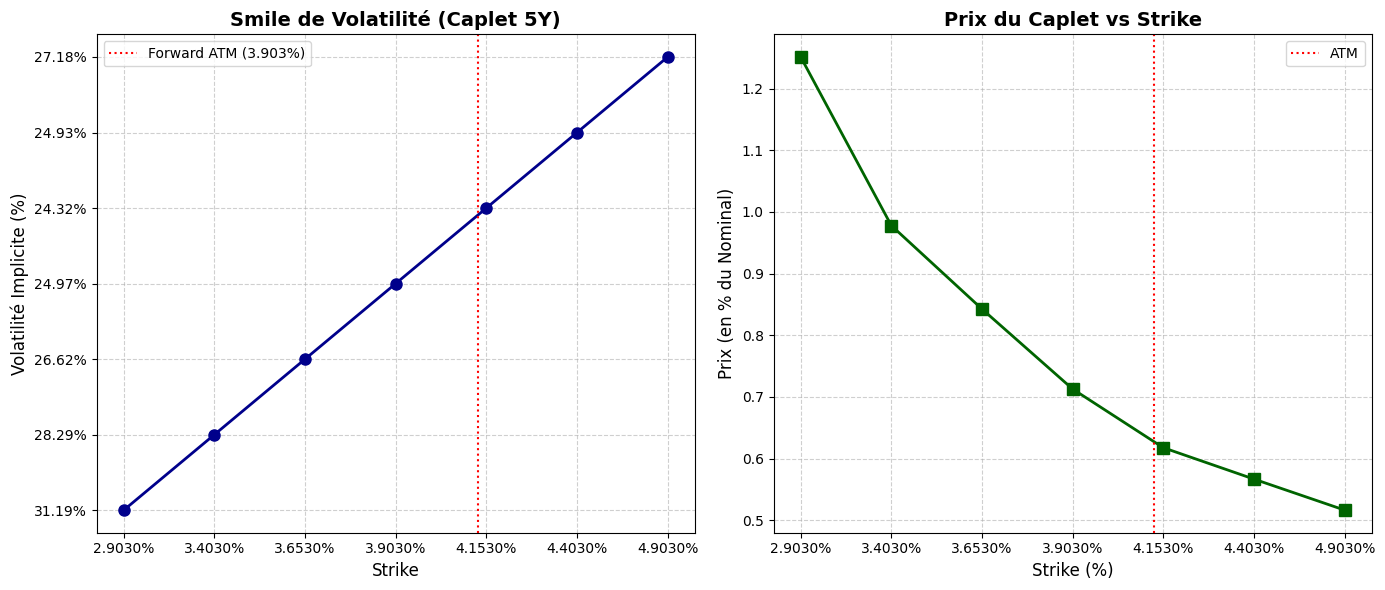

In [ ]:
df_plot = df_prices_prof.copy()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Graphique 1 : Le Smile de Volatilité ---
# On trace la Volatilité en fonction du Strike Absolu
ax1.plot(df_plot['Strike Absolu'], df_plot['Volatilité'],
         marker='o', linestyle='-', color='darkblue', linewidth=2, markersize=8)

# Mise en forme
ax1.set_title('Smile de Volatilité (Caplet 5Y)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Strike', fontsize=12)
ax1.set_ylabel('Volatilité Implicite (%)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)

# Ajout d'une ligne verticale pour le Forward (ATM)
atm_strike = 3.9030 # Le strike à 0 bps
ax1.axvline(x=atm_strike, color='red', linestyle=':', label=f'Forward ATM ({atm_strike}%)')
ax1.legend()

# --- Graphique 2 : Le Prix du Caplet ---
# On trace le Prix en fonction du Strike
ax2.plot(df_plot['Strike Absolu'], df_plot['Prix Caplet'],
         marker='s', linestyle='-', color='darkgreen', linewidth=2, markersize=8)

# Mise en forme
ax2.set_title('Prix du Caplet vs Strike', fontsize=14, fontweight='bold')
ax2.set_xlabel('Strike (%)', fontsize=12)
ax2.set_ylabel('Prix (en % du Nominal)', fontsize=12) # Supposé en % vu les valeurs > 1
ax2.grid(True, linestyle='--', alpha=0.6)

# Ajout d'une ligne verticale pour le Forward (ATM)
ax2.axvline(x=atm_strike, color='red', linestyle=':', label='ATM')
ax2.legend()

plt.tight_layout()
plt.show()

Dans 3.4, utiliser vriant lemme d'ito appliqué au processus Zt.  on va montrer que la dynamique du processus lit est log normale shiftée . ça génère du scew. c'est une des limitation du model uell white. Capature mal le scew, smile de volatilité.

